# 🎓 Computer Vision — OpenCV notes

A hands-on notebook: reading images, color spaces, geometry, arithmetic and thresholding.

**Stack:** `opencv-python` · `numpy` · `matplotlib`
**Run:** `.venv/bin/jupyter notebook` — from an **arm64** shell (`uname -m`); under Rosetta the arm64 wheels fail to import, see `how_to_run_jupyter.txt`

---

### 📑 Contents

0. [Imports and setup](#s0)
1. [Reading and displaying images](#s1)
2. [The main OpenCV trap: BGR instead of RGB](#s2)
3. [Splitting and merging channels](#s3)
4. [The HSV space](#s4)
5. [Checkpoint](#s5)
6. [Cropping and resizing](#s6)
7. [Drawing on an image](#s7)
8. [Arithmetic: brightness and contrast](#s8)
9. [Thresholding](#s9)
10. [Histogram](#s10)

[📌 What to fix](#fix) · [▶️ What's next](#next)

<a id="s0"></a>
## 0. Imports and setup

- `%matplotlib inline` — plots are drawn right under the cell.
- `IPython.display.Image` shows **the file as is**, without OpenCV — the colors are always correct, which is handy for comparison.

In [1]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline
from IPython.display import Image

<a id="s1"></a>
## 1. Reading and displaying images

Two different ways to show a picture:

| Way | What it does | Color |
|---|---|---|
| `Image(filename=...)` | hands the file itself to the browser | correct |
| `cv2.imread()` + `plt.imshow()` | reads into a NumPy array | **BGR** → needs conversion |

The second argument of `cv2.imread`:

- `0` = `cv2.IMREAD_GRAYSCALE` — grayscale, shape `(H, W)`
- `1` = `cv2.IMREAD_COLOR` — color, shape `(H, W, 3)`
- `-1` = `cv2.IMREAD_UNCHANGED` — with the alpha channel, if there is one

In [2]:
Image(filename='data/images/checkerboard_18x18_small.png')

### An image is just a matrix of numbers

An 18×18 checkerboard in grayscale: `0` is black, `255` is white. Sharp `0 → 255` transitions, no intermediate tones.

In [3]:
cb_imp = cv2.imread('data/images/checkerboard_18x18_small.png',0)
print(cb_imp)

[[255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255

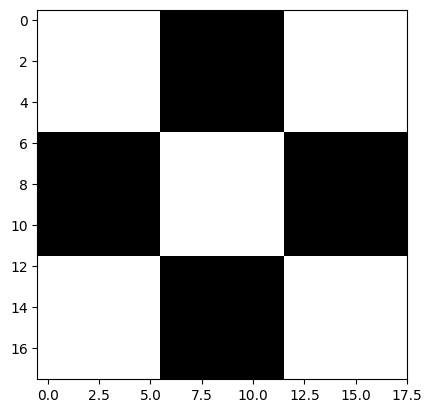

In [4]:
plt.imshow(cb_imp, cmap='gray')

### A blurred checkerboard

The same grid, but with soft edges — intermediate values appear between `0` and `255` (antialiasing).

> ⚠️ In the cell below, `print(cb_imp)` prints the **old** (sharp) matrix. To see the blurred one it has to be `print(cb_imp_f)`.

In [5]:
cb_imp_f = cv2.imread('data/images/checkerboard_18x18_fuzzy.png',0)
print(cb_imp)

[[255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255

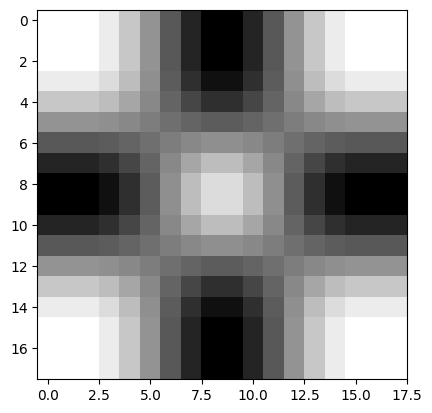

In [6]:
plt.imshow(cb_imp_f, cmap='gray')

<a id="s2"></a>
## 2. The main OpenCV trap: BGR instead of RGB

`cv2.imread` returns the channels in **B, G, R** order, while `plt.imshow` expects **R, G, B**. Without conversion, red turns blue.

Two ways to fix it:

- `img[:, :, ::-1]` — reverse the last axis (short, the NumPy way)
- `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` — explicit and readable

In [7]:
cb_imp_coca = cv2.imread('data/images/coco-cola.avif',1)


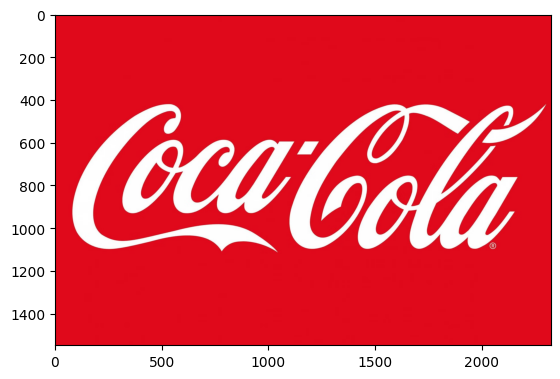

In [8]:
cb_imp_coca_reversed = cb_imp_coca[:,:,::-1]
plt.imshow(cb_imp_coca_reversed)

<a id="s3"></a>
## 3. Splitting and merging channels

`cv2.split(img)` → three separate 2D matrices. `cv2.merge((b, g, r))` puts them back together.

How to read a channel shown in gray: **bright = a lot of that color** in the pixel. The sky will be bright in the blue channel, grass in the green one.

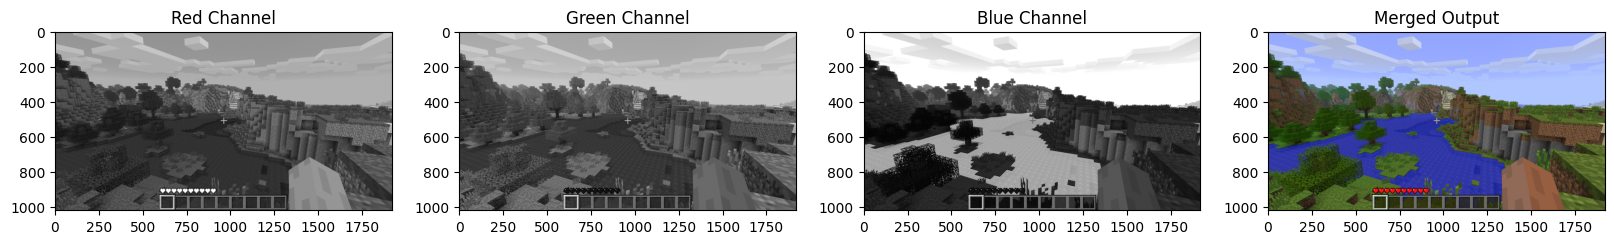

In [9]:
img_minecraft = cv2.imread("data/images/minecraft_screenshot.png",cv2.IMREAD_COLOR)
b,g,r = cv2.split(img_minecraft)
plt.figure(figsize=[20,5])

plt.subplot(141);plt.imshow(r,cmap='gray');plt.title("Red Channel");
plt.subplot(142);plt.imshow(g,cmap='gray');plt.title("Green Channel");
plt.subplot(143);plt.imshow(b,cmap='gray');plt.title("Blue Channel");

imgMerged = cv2.merge((b,g,r))

plt.subplot(144);plt.imshow(imgMerged[:,:,::-1]);plt.title("Merged Output");

### The right way: cvtColor

The same image, but through `cv2.cvtColor` — shorter, and without the risk of mixing up the channel order by hand.

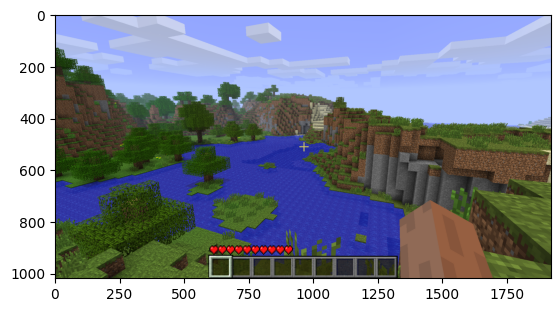

In [10]:
img_minecraft_bgr = cv2.imread("data/images/minecraft_screenshot.png",cv2.IMREAD_COLOR)
img_minecraft_rgb = cv2.cvtColor(img_minecraft_bgr,cv2.COLOR_BGR2RGB)
plt.imshow(img_minecraft_rgb)

<a id="s4"></a>
## 4. The HSV space

RGB is awkward when the task is "find everything red". HSV separates *which* color it is from *how bright* it is:

| Channel | Meaning | Range in OpenCV |
|---|---|---|
| **H** (Hue) | the hue — the color itself | **0–179** (not 0–359!) |
| **S** (Saturation) | saturation: gray → pure color | 0–255 |
| **V** (Value) | brightness | 0–255 |

That is exactly why color-based object search is done in HSV and not in RGB: the hue does not drift with lighting nearly as much.

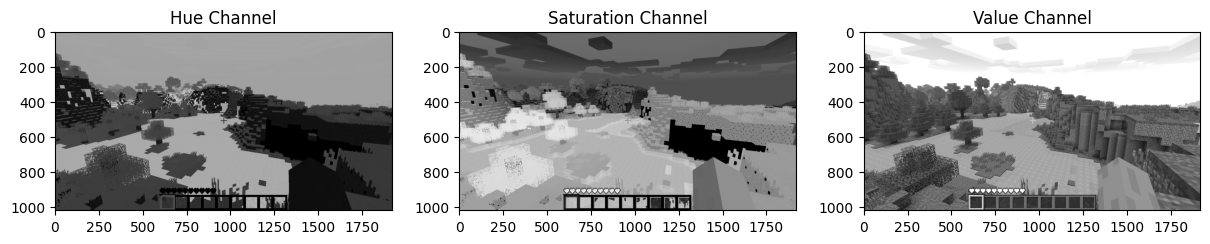

In [11]:
img_minecraft_hsv = cv2.cvtColor(img_minecraft_bgr,cv2.COLOR_BGR2HSV)
h,s,v = cv2.split(img_minecraft_hsv)

plt.figure(figsize=[20,5])
plt.subplot(141);plt.imshow(h,cmap='gray');plt.title("Hue Channel");
plt.subplot(142);plt.imshow(s,cmap='gray');plt.title("Saturation Channel");
plt.subplot(143);plt.imshow(v,cmap='gray');plt.title("Value Channel");

### Changing a channel and merging back

The idea: modify one channel (e.g. raise the saturation) → `cv2.merge` → `cv2.COLOR_HSV2RGB`.

> ⚠️ Two problems in the cell below:
> 1. `s_new = s` is **not a copy** but the same image, so "Modified" equals the original. It should be something like `s_new = np.clip(s * 1.5, 0, 255).astype("uint8")`.
> 2. `h_new` is never defined — after `Restart & Run All` this raises `NameError`. It should be `h`.

NameError: name 'h_new' is not defined

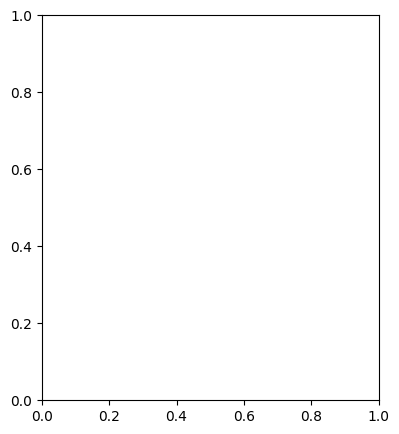

In [12]:
s_new = s 
img_minecraft_merged_new = cv2.merge((h,s_new,v))
img_minecraft_rgb_new = cv2.cvtColor(img_minecraft_merged_new, cv2.COLOR_HSV2RGB)

plt.figure(figsize=[20,5])
plt.subplot(141);plt.imshow(h_new,cmap='gray');plt.title("Hue Channel");
plt.subplot(142);plt.imshow(s,cmap='gray');plt.title("Saturation Channel");
plt.subplot(143);plt.imshow(v,cmap='gray');plt.title("Value Channel");
plt.subplot(144);plt.imshow(img_minecraft_rgb_new);plt.title("Modified")

<a id="s5"></a>
## 5. Checkpoint

Back to the checkerboard — to confirm that `imread(..., 0)` gives the same matrix as at the start.

In [ ]:
cb_imp = cv2.imread('data/images/checkerboard_18x18_small.png',0)

plt.imshow(cb_imp, cmap='gray')

In [ ]:
cb_imp = cv2.imread('data/images/checkerboard_18x18_small.png',0)
print(cb_imp)

In [ ]:
plt.imshow(img_minecraft_rgb_new)

<a id="s6"></a>
## 6. Cropping and resizing

**Crop** is a plain NumPy slice: `img[y1:y2, x1:x2]` — **rows (y)** first, then **columns (x)**.

**Resize** is `cv2.resize(img, dsize, fx=..., fy=...)`:

- `dsize=None` together with `fx`/`fy` — a scale factor
- or an explicit size — and here the order is **(width, height)**, the opposite of `.shape`

For downscaling prefer `interpolation=cv2.INTER_AREA`, for upscaling `cv2.INTER_CUBIC`.

In [ ]:
minecraft_cropped = img_minecraft_rgb_new[400:700,400:750]
plt.imshow(minecraft_cropped)

In [ ]:
minecraft_cropped_05x = cv2.resize(minecraft_cropped, None, fx=0.34, fy=0.34)
plt.imshow(minecraft_cropped_05x)

<a id="s7"></a>
## 7. Drawing on an image

> ⚠️ `plt.imshow(apollo_img)` below shows a BGR array without conversion — that is why the colors are inverted. Compare it with the next cell, which has `[:, :, ::-1]`.

`cv2.line(img, pt1, pt2, color, thickness, lineType)` draws **in place**, so `.copy()` first.
Coordinates are given as `(x, y)`, the color in **BGR**. `cv2.LINE_AA` means an antialiased line.

`cv2.circle`, `cv2.rectangle`, `cv2.ellipse` and `cv2.putText` work the same way.

In [ ]:
apollo_img = cv2.imread("data/images/apollo.webp")
plt.imshow(apollo_img)

In [ ]:
imageLine = apollo_img.copy()
cv2.line(imageLine,(200,100),(400,100),(0,255,255),thickness=5,lineType=cv2.LINE_AA)
plt.imshow(imageLine[:,:,::-1])

<a id="s8"></a>
## 8. Arithmetic: brightness and contrast

**Brightness** — add or subtract a constant: `cv2.add`, `cv2.subtract`.

Why those and not `+` / `-`: OpenCV does **saturating** arithmetic (clamps to `0…255`), while NumPy on `uint8` wraps around — `250 + 10` gives `4`.

In [ ]:
matrix = np.ones(apollo_img.shape,dtype = "uint8") * 50

apollo_img_brighter = cv2.add(apollo_img,matrix)
apollo_img_darker = cv2.subtract(apollo_img,matrix)

plt.figure(figsize=[20,5])
plt.subplot(141);plt.imshow(apollo_img_brighter,cmap='gray');plt.title("Drighter");
plt.subplot(142);plt.imshow(apollo_img,cmap='gray');plt.title("Normal");
plt.subplot(143);plt.imshow(apollo_img_darker,cmap='gray');plt.title("Darker");

### Contrast — multiplication

> ⚠️ **The cell below does not do what it looks like.**
> `np.ones(shape, dtype="uint8") * 0.7` → the fraction is truncated to an integer, so the matrix becomes **0** (everything black), and `* 1.5` becomes **1** (no change at all).
>
> The right way is to multiply directly, with clipping:
> ```python
> apollo_img_lower  = np.uint8(np.clip(apollo_img * 0.7, 0, 255))
> apollo_img_higher = np.uint8(np.clip(apollo_img * 1.5, 0, 255))
> ```

In [ ]:
matrix_08 = np.ones(apollo_img.shape,dtype = "uint8") * 0.7
matrix_12 = np.ones(apollo_img.shape,dtype = "uint8") * 1.5

apollo_img_lower = np.uint8(cv2.multiply(np.float64(apollo_img),matrix_08))
apollo_img_higher = np.uint8(np.clip(cv2.multiply(np.float64(apollo_img),matrix_12),0,255))

plt.figure(figsize=[20,5])
plt.subplot(141);plt.imshow(apollo_img_lower,cmap='gray');plt.title("Lower");
plt.subplot(142);plt.imshow(apollo_img,cmap='gray');plt.title("Normal");
plt.subplot(143);plt.imshow(apollo_img_higher,cmap='gray');plt.title("Higher");

<a id="s9"></a>
## 9. Thresholding

The goal is to turn a grayscale image into a **binary** mask: black/white, no intermediate tones.

`retval, dst = cv2.threshold(src, thresh, maxval, type)`

| Approach | When it fits |
|---|---|
| Fixed threshold | even lighting, the threshold is known in advance |
| **Otsu** (`+ cv2.THRESH_OTSU`) | the threshold is picked automatically from the histogram; needs two pronounced peaks |
| **Adaptive** (`cv2.adaptiveThreshold`) | uneven lighting — the threshold is computed locally for each region |

*(the cell below just prints the current `retval` — a leftover from experimenting)*

In [ ]:
retval

### Otsu: a scanned page with formulas

The `thresh=0` argument is ignored here — Otsu finds the threshold itself and returns it in `retval`.

In [ ]:
formulas_img = cv2.imread("data/images/formulas.jpg", cv2.IMREAD_GRAYSCALE)
retval, formulas_otsu = cv2.threshold(formulas_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Otsu picked T =", retval)
plt.imshow(formulas_otsu, cmap='gray')

### Adaptive: the same page

`cv2.adaptiveThreshold(src, maxValue, adaptiveMethod, thresholdType, blockSize, C)`

- `blockSize=11` — the size of the local window, **odd only**
- `C=7` — how much to subtract from the local mean; a larger `C` means less noise, but thin lines disappear

Compare with Otsu above: adaptive wins where the scan is darkened along one edge.

In [ ]:
formulas_adp = cv2.adaptiveThreshold(formulas_img, 255,cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY ,11,7)

plt.imshow(formulas_adp, cmap='gray')

### Tank: a scene with uneven lighting

> ⚠️ `tank_img` is never read — there is no `tank_img = cv2.imread("data/images/tank.webp", cv2.IMREAD_GRAYSCALE)` cell. This only worked because the variable was still in the kernel's memory; after `Restart & Run All` it raises `NameError`.

In [ ]:
tank_img = cv2.imread("data/images/tank.webp", cv2.IMREAD_GRAYSCALE)
retval, tank_otsu = cv2.threshold(tank_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Otsu picked T =", retval)
plt.imshow(tank_otsu, cmap='gray')


In [ ]:
tank_adp = cv2.adaptiveThreshold(tank_img, 255,cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY ,11,7)

plt.imshow(tank_adp, cmap='gray')


### Fixed threshold: building windows

Here the threshold is set by hand (`100`) — the windows are much darker than the facade, so they separate even without Otsu.
The first `imread` without a flag is redundant: the next line overwrites the variable right away.

In [ ]:
windows_img = cv2.imread("data/images/building_windows.avif")

windows_img = cv2.imread("data/images/building_windows.avif", cv2.IMREAD_GRAYSCALE)
retval,windows_treshold = cv2.threshold(windows_img, 100, 255, cv2.THRESH_BINARY)
plt.imshow(windows_treshold, cmap = 'gray')


<a id="s10"></a>
## 10. Histogram

`plt.hist(img.ravel(), 256, [0, 256])` — the distribution of intensities; `.ravel()` flattens the 2D matrix into a 1D vector.

For a **binary** image the histogram has only two bars — `0` and `255`. It is more interesting to look at the histogram *before* thresholding (`tank_img`), to see between which peaks Otsu placed the threshold.

In [ ]:
plt.hist(tank_otsu.ravel(), 256, [0,256])

---

<a id="fix"></a>
## 📌 What to fix (found during review)

| Place | Problem | Fix |
|---|---|---|
| blurred checkerboard | `print(cb_imp)` instead of `cb_imp_f` | swap the variable |
| HSV merge | `s_new = s` — no copy; `h_new` undefined | `s_new = np.clip(s*1.5, 0, 255).astype("uint8")`, `h_new` → `h` |
| brightness | the plot title says `"Drighter"` | → `"Brighter"` |
| contrast | a `uint8` matrix built from `0.7` / `1.5` truncates to `0` / `1` | multiply the float directly + `np.clip` |
| Otsu for the tank | `tank_img` is never read | add `tank_img = cv2.imread("data/images/tank.webp", cv2.IMREAD_GRAYSCALE)` |

> 💡 Health check for the notebook: **Kernel → Restart & Run All**. If it goes through without a `NameError`, there are no dependencies on leftovers in memory.

<a id="next"></a>
## ▶️ What's next

- **Smoothing and noise:** `cv2.GaussianBlur`, `cv2.medianBlur`, `cv2.bilateralFilter`
- **Edges:** `cv2.Canny`, `cv2.Sobel`, `cv2.Laplacian`
- **Morphology:** `cv2.erode`, `cv2.dilate`, `cv2.morphologyEx` — remove holes in masks after thresholding
- **Contours:** `cv2.findContours` + `cv2.drawContours` — from a mask to objects